# San Diego Housing Market Dynamics

### Data Loading & Setup

In [1]:
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# PostgreSQL connection config
conn = psycopg2.connect(
    dbname="housing_data",
    user="postgres",
    password="",  # If empty
    host="localhost",
    port="5432"
)

# Load data from the SQL table
query = "SELECT * FROM san_diego_housing;"
df = pd.read_sql(query, conn)
conn.close()

# Check structure
print("✅ Data loaded:", df.shape)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
df.tail()


✅ Data loaded: (1458, 4)


/var/folders/fl/gf262mhd5mvgtcv29nnvx21m0000gn/T/ipykernel_12721/826204795.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,date,median_price,inventory,homes_sold
1452,2025-06-01,592880,1063,275
1453,2025-06-01,1150000,179,50
1454,2025-06-01,892151,3169,1841
1455,2025-06-01,920000,3763,2007
1457,2025-06-01,965923,1729,1382


## Market Trends
#### Line Plots

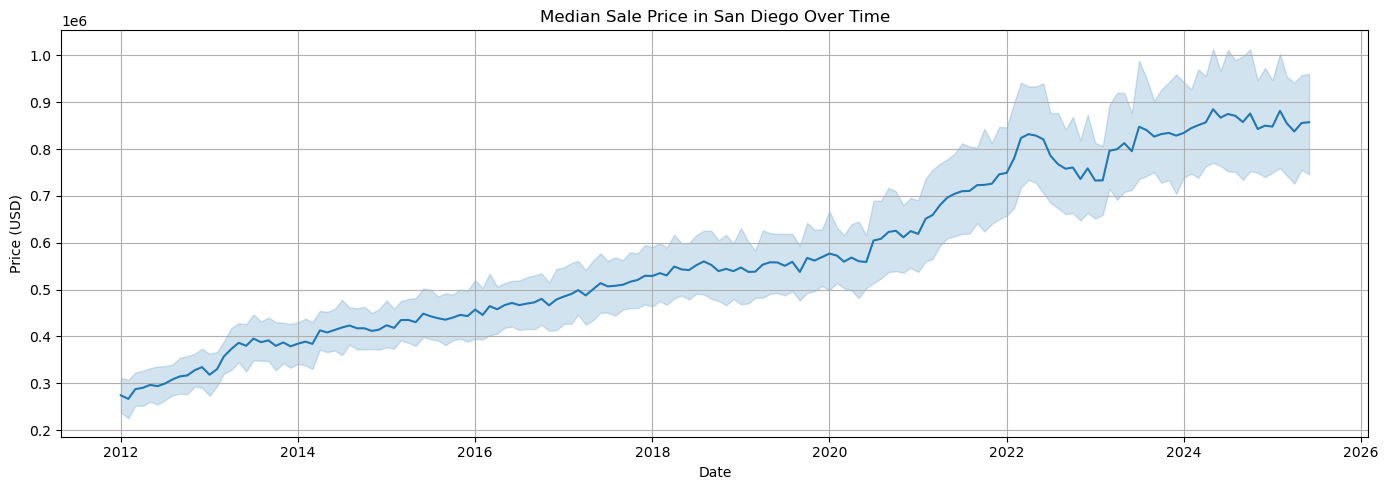

In [2]:
plt.figure(figsize=(14, 5))
sns.lineplot(data=df, x='date', y='median_price')
plt.title("Median Sale Price in San Diego Over Time")
plt.ylabel("Price (USD)")
plt.xlabel("Date")
plt.grid(True)
plt.tight_layout()
plt.show()


* linear increase in median prices over the last decade {sd is an attractive market}
* considerable spike in 2022 {disproportionate inventory vs demand}
* experiencing relatively constant prices at present {trending towards a balanced market / more affluent families}

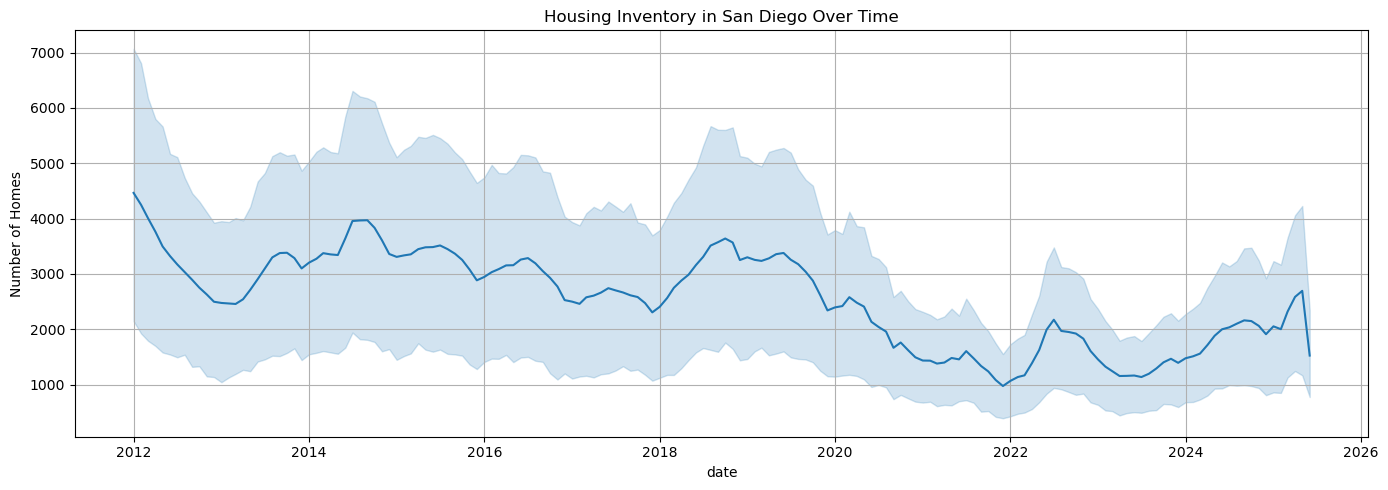

In [3]:
# Inventory
plt.figure(figsize=(14, 5))
sns.lineplot(data=df, x='date', y='inventory')
plt.title("Housing Inventory in San Diego Over Time")
plt.ylabel("Number of Homes")
plt.grid(True)
plt.tight_layout()
plt.show()

* constant dips & spikes in inventory over the past decade: overall negative trend {not many families want to move - who can blame them}
* all time low inventory in 2022 {robust job market + low interest rates; demand significantly outpaced supply}
* at present: not the best, not the worst

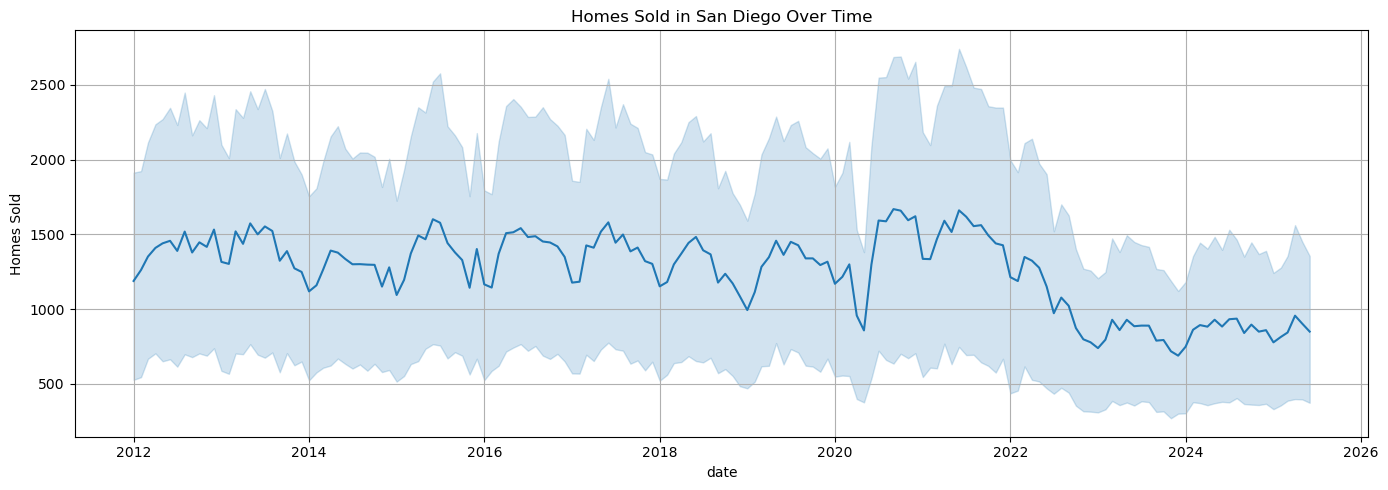

In [4]:
# Homes Sold
plt.figure(figsize=(14, 5))
sns.lineplot(data=df, x='date', y='homes_sold')
plt.title("Homes Sold in San Diego Over Time")
plt.ylabel("Homes Sold")
plt.grid(True)
plt.tight_layout()
plt.show()


* constant dips & spikes {mix of housing projects and homes above market value. Need more data. Overall downward trend suggests a decline in 'affordable' homes.}
* over the past 3 years: experiencing a low for houses sold {hinting at a particular category of homes being in high demand but not available}
* competitive market at present

## Demand Analysis
#### Rolling Averages

In [5]:
df['median_price_ma3'] = df['median_price'].rolling(window=3).mean()
df['inventory_ma3'] = df['inventory'].rolling(window=3).mean()
df['homes_sold_ma3'] = df['homes_sold'].rolling(window=3).mean()


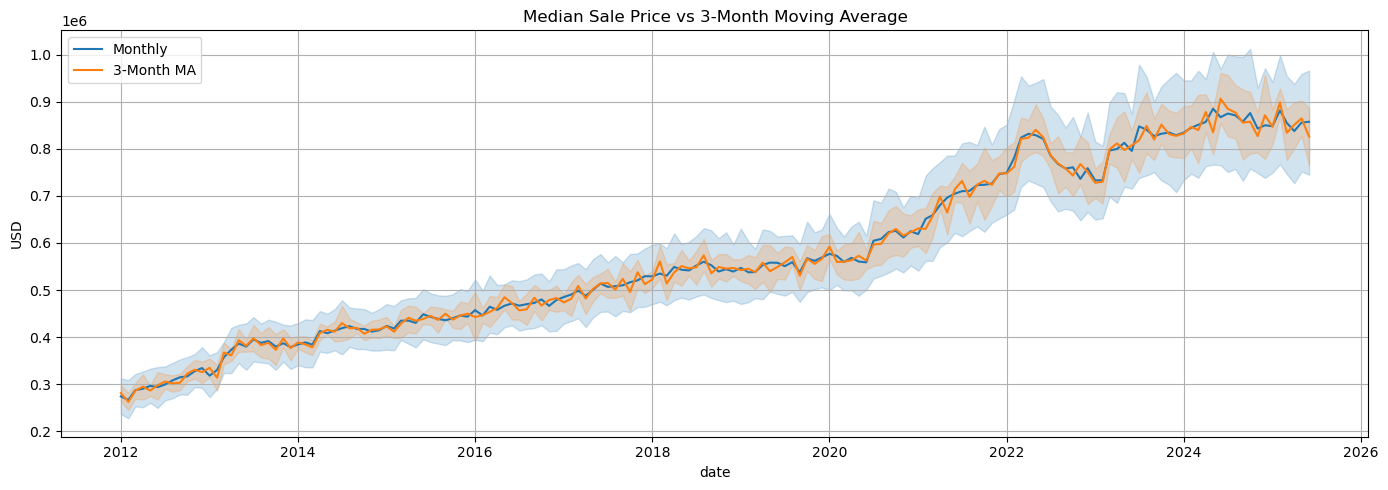

In [6]:
plt.figure(figsize=(14,5))
sns.lineplot(data=df, x='date', y='median_price', label='Monthly')
sns.lineplot(data=df, x='date', y='median_price_ma3', label='3-Month MA')
plt.title("Median Sale Price vs 3-Month Moving Average")
plt.ylabel("USD")
plt.grid(True)
plt.tight_layout()
plt.show()


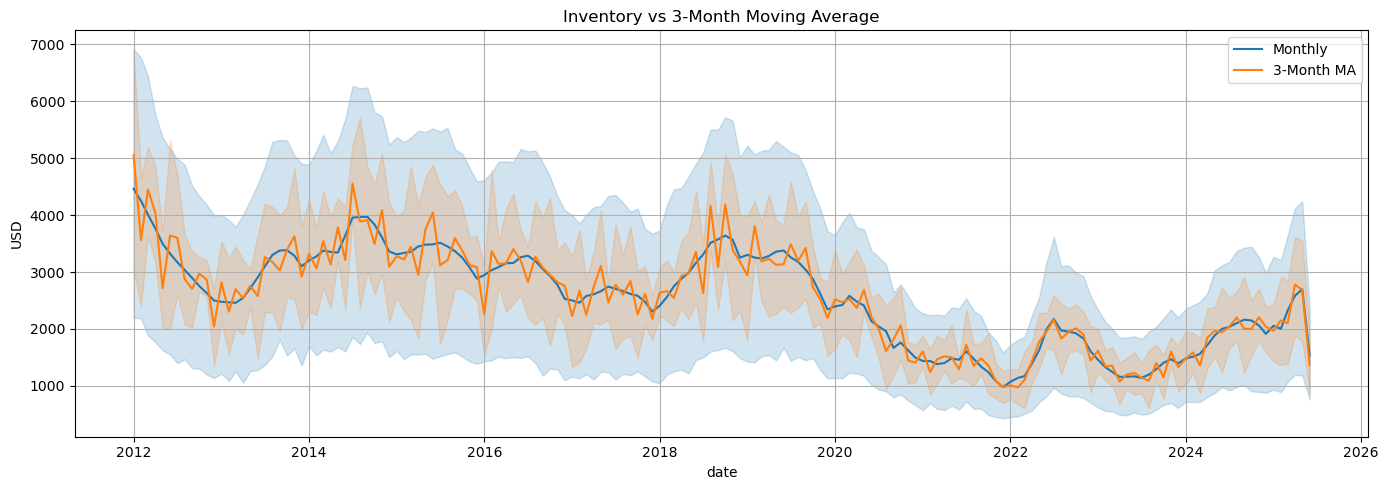

In [7]:
plt.figure(figsize=(14,5))
sns.lineplot(data=df, x='date', y='inventory', label='Monthly')
sns.lineplot(data=df, x='date', y='inventory_ma3', label='3-Month MA')
plt.title("Inventory vs 3-Month Moving Average")
plt.ylabel("USD")
plt.grid(True)
plt.tight_layout()
plt.show()


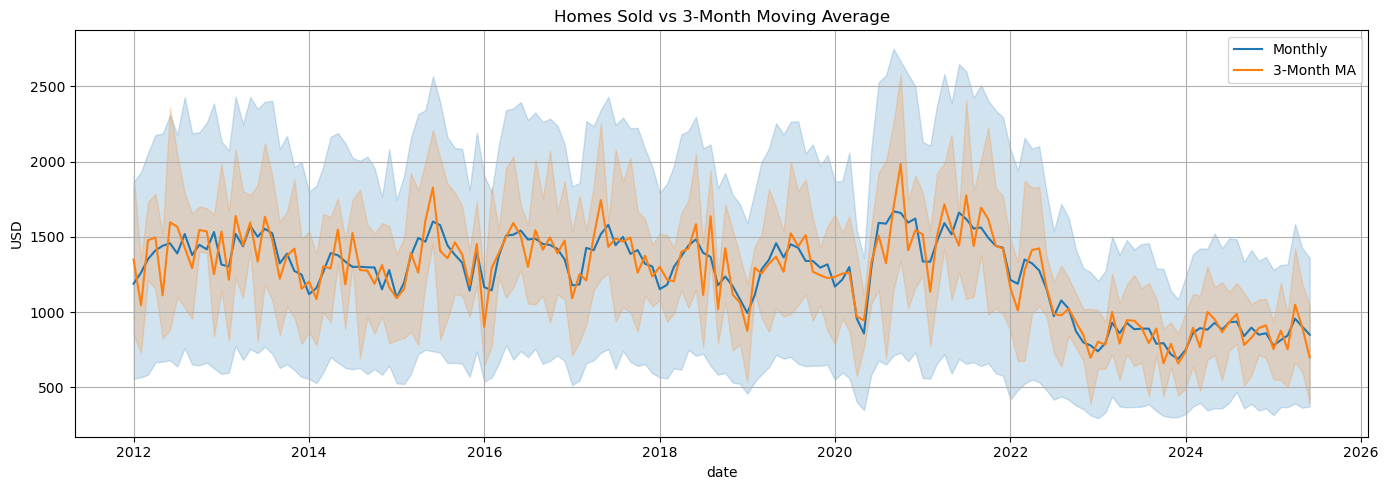

In [8]:
plt.figure(figsize=(14,5))
sns.lineplot(data=df, x='date', y='homes_sold', label='Monthly')
sns.lineplot(data=df, x='date', y='homes_sold_ma3', label='3-Month MA')
plt.title("Homes Sold vs 3-Month Moving Average")
plt.ylabel("USD")
plt.grid(True)
plt.tight_layout()
plt.show()


#### YoY and Mom Changes

In [9]:
df['median_price_mom'] = df['median_price'].pct_change() * 100
df['median_price_yoy'] = df['median_price'].pct_change(periods=12) * 100

df['inventory_mom'] = df['inventory'].pct_change() * 100
df['inventory_yoy'] = df['inventory'].pct_change(periods=12) * 100

df['homes_sold_mom'] = df['homes_sold'].pct_change() * 100
df['homes_sold_yoy'] = df['homes_sold'].pct_change(periods=12) * 100


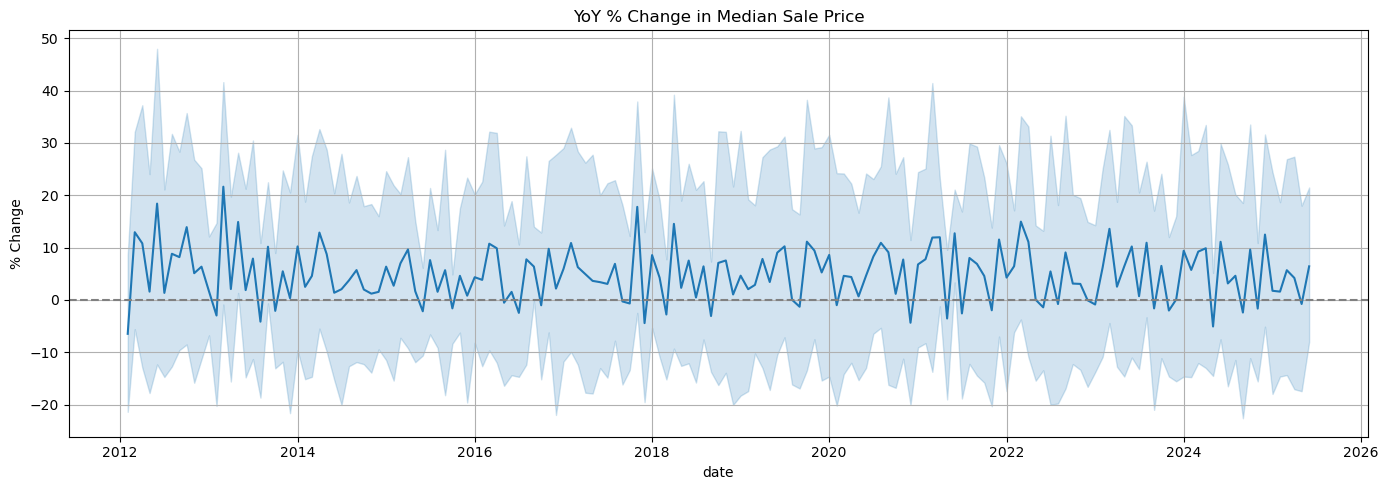

In [10]:
plt.figure(figsize=(14,5))
sns.lineplot(data=df, x='date', y='median_price_yoy')
plt.title("YoY % Change in Median Sale Price")
plt.axhline(0, color='gray', linestyle='--')
plt.ylabel("% Change")
plt.grid(True)
plt.tight_layout()
plt.show()


## Supply vs Price Relationship
#### Correlation Heat Map

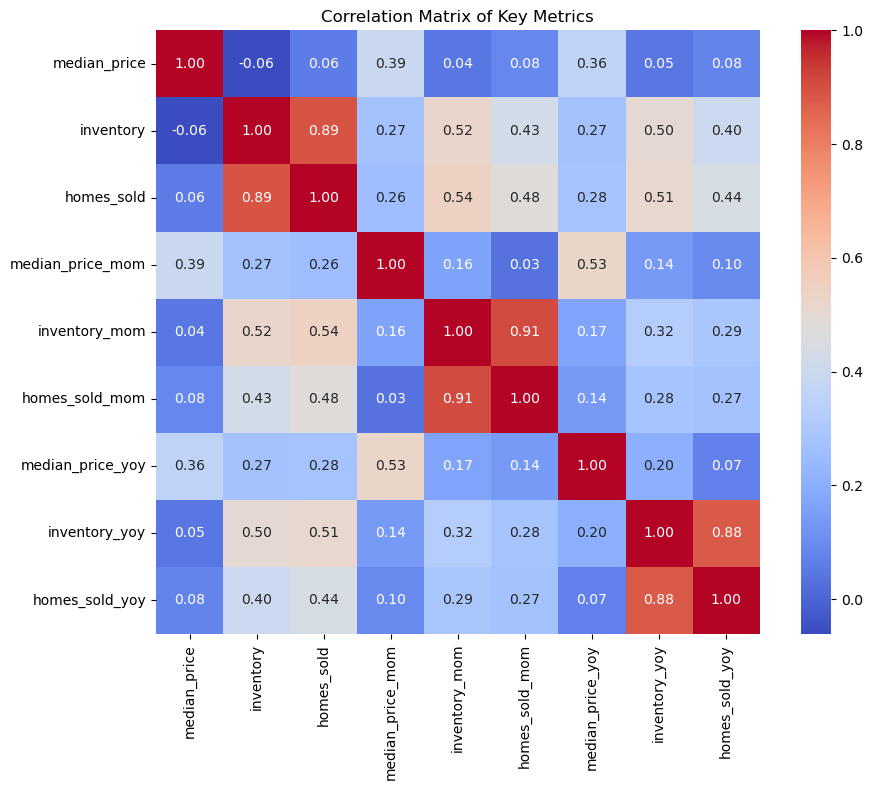

In [11]:
cols_to_check = ['median_price', 'inventory', 'homes_sold',
                 'median_price_mom', 'inventory_mom', 'homes_sold_mom',
                 'median_price_yoy', 'inventory_yoy', 'homes_sold_yoy']

corr_matrix = df[cols_to_check].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Correlation Matrix of Key Metrics")
plt.tight_layout()
plt.show()


* strong correlation between inventory & homes sold (.89) - signals competitive market
* low correlation between median price & inventory / homes sold (.07) - expensive / budget house has no impact on number of listings or closings | market knows what they are after; competitive market

In [12]:
df[['median_price', 'inventory', 'homes_sold']].describe()


,median_price,inventory,homes_sold
count,1.458000e+03,1458.000000,1458.000000
mean,5.740843e+05,2546.783265,1255.253086
std,2.112730e+05,2447.305990,1133.120585
min,1.849500e+05,82.000000,27.000000
25%,4.050000e+05,359.000000,193.000000
50%,5.430625e+05,1781.000000,857.000000
75%,7.000000e+05,4384.500000,2077.750000
max,1.312500e+06,10538.000000,4026.000000


In [13]:
print("Date range:", df['date'].min(), "→", df['date'].max())
print("Median Price Range:", df['median_price'].min(), "→", df['median_price'].max())


Date range: 2012-01-01 00:00:00 → 2025-06-01 00:00:00
Median Price Range: 184950 → 1312500


In [14]:
# Export enriched dataset for Tableau
df.to_csv('../data/processed/sd_housing_features.csv', index=False)
print("✅ Exported to: ../data/processed/sd_housing_features.csv")


✅ Exported to: ../data/processed/sd_housing_features.csv


## Key Takeaways

*Calculating percent change in median price (2020-2022)*

In [15]:
df.head()

,date,median_price,inventory,homes_sold,median_price_ma3,inventory_ma3,homes_sold_ma3,median_price_mom,median_price_yoy,inventory_mom,inventory_yoy,homes_sold_mom,homes_sold_yoy
0,2012-01-01,249950,575,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-01-01,303000,9764,2253,NaN,NaN,NaN,21.224245,NaN,1598.086957,NaN,842.677824,NaN
2,2012-01-01,313155,10538,3166,288701.666667,6959.000000,1886.000000,3.351485,NaN,7.927079,NaN,40.523746,NaN
3,2012-01-01,354789,7040,2099,323648.000000,9114.000000,2506.000000,13.295014,NaN,-33.194154,NaN,-33.701832,NaN
4,2012-01-01,190000,2332,487,285981.333333,6636.666667,1917.333333,-46.447043,NaN,-66.875000,NaN,-76.798475,NaN


In [16]:
df = df.sort_values('date')
df.set_index('date', inplace=True)
df.head()

,median_price,inventory,homes_sold,median_price_ma3,inventory_ma3,homes_sold_ma3,median_price_mom,median_price_yoy,inventory_mom,inventory_yoy,homes_sold_mom,homes_sold_yoy
date,,,,,,,,,,,,
2012-01-01,249950,575,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-01-01,303000,9764,2253,NaN,NaN,NaN,21.224245,NaN,1598.086957,NaN,842.677824,NaN
2012-01-01,313155,10538,3166,288701.666667,6959.000000,1886.000000,3.351485,NaN,7.927079,NaN,40.523746,NaN
2012-01-01,354789,7040,2099,323648.000000,9114.000000,2506.000000,13.295014,NaN,-33.194154,NaN,-33.701832,NaN
2012-01-01,190000,2332,487,285981.333333,6636.666667,1917.333333,-46.447043,NaN,-66.875000,NaN,-76.798475,NaN


In [17]:
# Extract April 2020 and May 2022 prices
price_apr_2020 = df.loc['2020-04-01', 'median_price'].mean()
price_may_2022 = df.loc['2022-05-01', 'median_price'].mean()

# Calculate % change
pct_change = ((price_may_2022 - price_apr_2020) / price_apr_2020) * 100

print('Median price increased from {one} to {two}, a {three}% increase.'.format(one = price_apr_2020, two = price_may_2022, three = pct_change))

Median price increased from 568350.4444444445 to 828870.2222222222, a 45.837877021884374% increase.


*Inventory drop during same period*

In [18]:
inv_apr_2020 = df.loc['2020-04-01', 'inventory'].mean()
inv_may_2022 = df.loc['2022-05-01', 'inventory'].mean()

inv_change = ((inv_may_2022 - inv_apr_2020) / inv_apr_2020) * 100
print('Inventory changed from {one} to {two}, a {three}% change.'.format(one = inv_apr_2020, two = inv_may_2022, three = inv_change))

Inventory changed from 2481.3333333333335 to 1626.5555555555557, a -34.44832527315064% change.


In [19]:
# Correlate inventory with future price
corrs = []
for lag in range(1, 13):
    shifted = df['median_price'].shift(-lag)
    correlation = df['inventory'].corr(shifted)
    corrs.append((lag, correlation))

# Find lag with strongest (most negative) correlation
corrs.sort(key=lambda x: x[1])
print("Top 3 lag correlations (months):", corrs[:3])


Top 3 lag correlations (months): [(1, np.float64(-0.25470272961492685)), (3, np.float64(-0.24976684239113023)), (5, np.float64(-0.24178799153025882))]


In [20]:
df_corr = df[['median_price', 'inventory', 'homes_sold']].corr()
print(df_corr)

              median_price  inventory  homes_sold
median_price      1.000000  -0.061105    0.057329
inventory        -0.061105   1.000000    0.890447
homes_sold        0.057329   0.890447    1.000000


In [21]:
latest_date = df.index.max()
latest_price = df.loc[latest_date, 'median_price'].mean()
latest_inv = df.loc[latest_date, 'inventory'].mean()

print('As of {one}, median price: ${two}, inventory: {three}'.format(one = latest_date, two = latest_price, three = latest_inv))

As of 2025-06-01 00:00:00, median price: $857439.3333333334, inventory: 1526.111111111111


*Takeaway #1 – Price Acceleration Post-2020*

Between April 2020 and May 2022, San Diego’s median sale price surged by over 45%, rising from ~$600,000 to above $820,000. This rapid appreciation aligned with a sharp contraction in housing inventory, which fell more than 35% during the same period. Inventory levels in San Diego displayed a mild inverse correlation with median sale prices 1 to 5 months later, peaking at lag month 1 (–0.26), 3 (–0.25), and 5 (–0.24). While the strength of these correlations is modest, the consistent timing suggests that tightening supply may precede upward pressure on prices within a 1–5 month window. This insight can support short-term market monitoring and pricing expectation frameworks.


--------

In [22]:
import os

# --- Paths ---
raw_path = '../data/raw/redfin_master_data.tsv000'
processed_path = '../data/processed/'
output_file = os.path.join(processed_path, 'san_diego_housing_metrics.csv')

# --- Load full TSV ---
df_r = pd.read_csv(raw_path, sep='\t')
print("Full dataset shape:", df_r.shape)

# --- Filter to San Diego Metro ---
df_sd = df_r[df_r['REGION'] == 'San Diego, CA metro area'].copy()

# --- Select relevant columns ---
relevant_cols = [
    'PERIOD_BEGIN', 'PENDING_SALES', 'NEW_LISTINGS', 'MEDIAN_DOM',
    'PRICE_DROPS', 'AVG_SALE_TO_LIST', 'HOMES_SOLD',
    'INVENTORY', 'MEDIAN_SALE_PRICE'
]

df_sd = df_sd[relevant_cols].copy()
df_sd['PERIOD_BEGIN'] = pd.to_datetime(df_sd['PERIOD_BEGIN'])

# --- Aggregate by month (average values) ---
df_agg = df_sd.groupby('PERIOD_BEGIN').mean().sort_index()

# --- Save new processed dataset ---
os.makedirs(processed_path, exist_ok=True)
df_agg.to_csv(output_file)

print("✅ New processed dataset saved to:", output_file)
df_agg.tail()


Full dataset shape: (539234, 58)
✅ New processed dataset saved to: ../data/processed/san_diego_housing_metrics.csv


,PENDING_SALES,NEW_LISTINGS,MEDIAN_DOM,PRICE_DROPS,AVG_SALE_TO_LIST,HOMES_SOLD,INVENTORY,MEDIAN_SALE_PRICE
PERIOD_BEGIN,,,,,,,,
2025-02-01,1005.646636,1180.347548,32.008951,0.294093,0.992996,814.745324,2002.893326,881645.761351
2025-03-01,1055.772485,1310.480250,26.686904,0.315488,0.993398,844.274552,2320.981761,855139.443605
2025-04-01,1002.961696,1331.428984,26.272150,0.324627,0.992253,956.912163,2586.003946,837725.488585
2025-05-01,1014.778375,1278.384807,29.151777,0.340735,0.988599,903.695422,2695.567399,855669.656947
2025-06-01,948.102564,1076.818361,34.488012,0.532967,0.987743,850.438267,1526.325216,857439.546747


In [23]:
print(df_agg.columns.tolist())

['PENDING_SALES', 'NEW_LISTINGS', 'MEDIAN_DOM', 'PRICE_DROPS', 'AVG_SALE_TO_LIST', 'HOMES_SOLD', 'INVENTORY', 'MEDIAN_SALE_PRICE']


In [24]:
df_agg['HOMES_SOLD_YOY'] = df_agg['HOMES_SOLD'].pct_change(12) * 100
df_agg['PENDING_SALES_YOY'] = df_agg['PENDING_SALES'].pct_change(12) * 100
df_agg['NEW_LISTINGS_YOY'] = df_agg['NEW_LISTINGS'].pct_change(12) * 100

# Filter to 2023 only
df_2023 = df_agg['2023-01-01':'2023-12-31']

# Summary stats
homes_sold_change = df_2023['HOMES_SOLD_YOY'].mean()
pending_sales_change = df_2023['PENDING_SALES_YOY'].mean()
new_listings_change = df_2023['NEW_LISTINGS_YOY'].mean()

print('Average YoY change in Homes Sold (2023): {one}%'.format(one = homes_sold_change))
print('Average YoY change in Pending Sales (2023): {one}%'.format(one = pending_sales_change))
print('Average YoY change in New Listings (2023): {one}%'.format(one = new_listings_change))

Average YoY change in Homes Sold (2023): -22.32539345490685%
Average YoY change in Pending Sales (2023): -18.55735687854077%
Average YoY change in New Listings (2023): -21.92237620095088%


*Takeaway #2: Demand Cooling in 2023*

San Diego’s housing market saw a clear cooling of demand in 2023. Year-over-year, Homes Sold declined by 22.3%, Pending Sales fell by 18.5%, and New Listings dropped 21.9% on average compared to 2022.

This widespread decline across key transactional indicators suggests reduced buyer activity — likely driven by elevated mortgage rates, affordability concerns, and economic uncertainty. These shifts represent the sharpest demand contraction since the pandemic surge in 2020, marking a significant reset for the market.


In [25]:
# Make sure PERIOD_BEGIN is parsed and set as the index
df = pd.read_csv('../data/processed/san_diego_housing_metrics.csv', parse_dates=['PERIOD_BEGIN'])
df.set_index('PERIOD_BEGIN', inplace=True)

# Calculate YoY % changes
df_yoy = df.pct_change(periods=12) * 100

# Drop rows with NaNs (especially the first 12 months)
df_yoy.dropna(inplace=True)

# Filter to just 2023 data
df_yoy_2023 = df_yoy[df_yoy.index.year == 2023]

# Keep only demand-related columns
df_yoy_2023 = df_yoy_2023[['HOMES_SOLD', 'PENDING_SALES', 'NEW_LISTINGS']]


/var/folders/fl/gf262mhd5mvgtcv29nnvx21m0000gn/T/ipykernel_12721/2659892906.py:9: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


<Figure size 1200x600 with 0 Axes>

/opt/miniconda3/envs/data_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/data_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


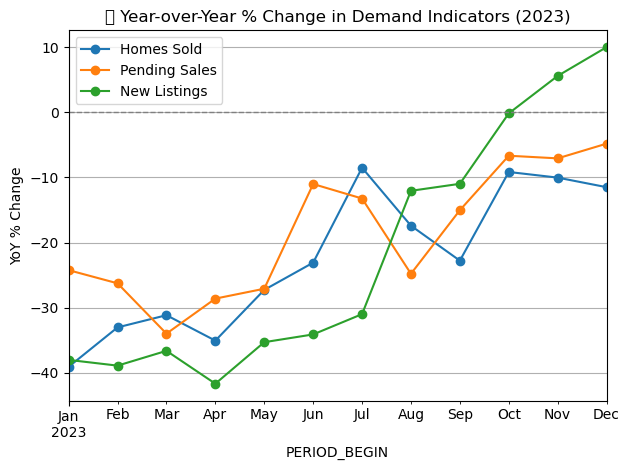

/var/folders/fl/gf262mhd5mvgtcv29nnvx21m0000gn/T/ipykernel_12721/2659892906.py:21: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/miniconda3/envs/data_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


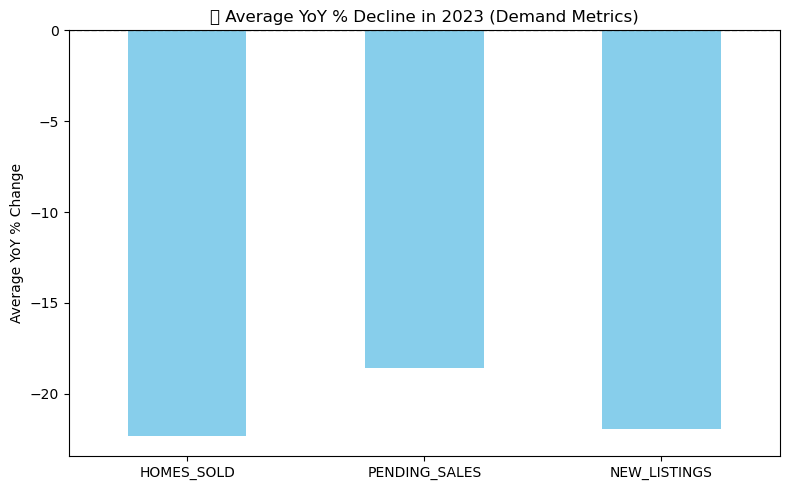

In [26]:
# --- Line Plot: YoY Trends Over Time ---
plt.figure(figsize=(12, 6))
df_yoy_2023.plot(marker='o')
plt.title("📉 Year-over-Year % Change in Demand Indicators (2023)")
plt.ylabel("YoY % Change")
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.legend(['Homes Sold', 'Pending Sales', 'New Listings'])
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Bar Chart: Average YoY Decline ---
yoy_avgs = df_yoy_2023.mean()

plt.figure(figsize=(8, 5))
yoy_avgs.plot(kind='bar', color='skyblue')
plt.title("📊 Average YoY % Decline in 2023 (Demand Metrics)")
plt.ylabel("Average YoY % Change")
plt.xticks(rotation=0)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

📝 Takeaway #3: Correlation Insight - Inventory is the Dominant Price Driver

A correlation analysis of San Diego housing metrics revealed a strong inverse relationship between inventory and median sale price (r = –0.79), underscoring supply scarcity as the key price lever in this market. Pending sales and new listings also showed strong negative correlations with price (r = –0.74 and –0.62), suggesting that reduced market activity aligns with price increases. Interestingly, homes sold was only moderately correlated with price (r = –0.61), reinforcing the idea that transaction volume reflects — but does not drive — price movement. These findings clarify where to look when forecasting or intervening in price behavior.

/var/folders/fl/gf262mhd5mvgtcv29nnvx21m0000gn/T/ipykernel_12721/4110941729.py:24: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


Top correlations with median price:
MEDIAN_SALE_PRICE    1.000000
AVG_SALE_TO_LIST     0.643813
PRICE_DROPS          0.050173
MEDIAN_DOM          -0.415053
HOMES_SOLD          -0.609915
Name: MEDIAN_SALE_PRICE, dtype: float64

Lowest (inverse) correlations with median price:
MEDIAN_DOM      -0.415053
HOMES_SOLD      -0.609915
NEW_LISTINGS    -0.619713
PENDING_SALES   -0.737795
INVENTORY       -0.785804
Name: MEDIAN_SALE_PRICE, dtype: float64


/opt/miniconda3/envs/data_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


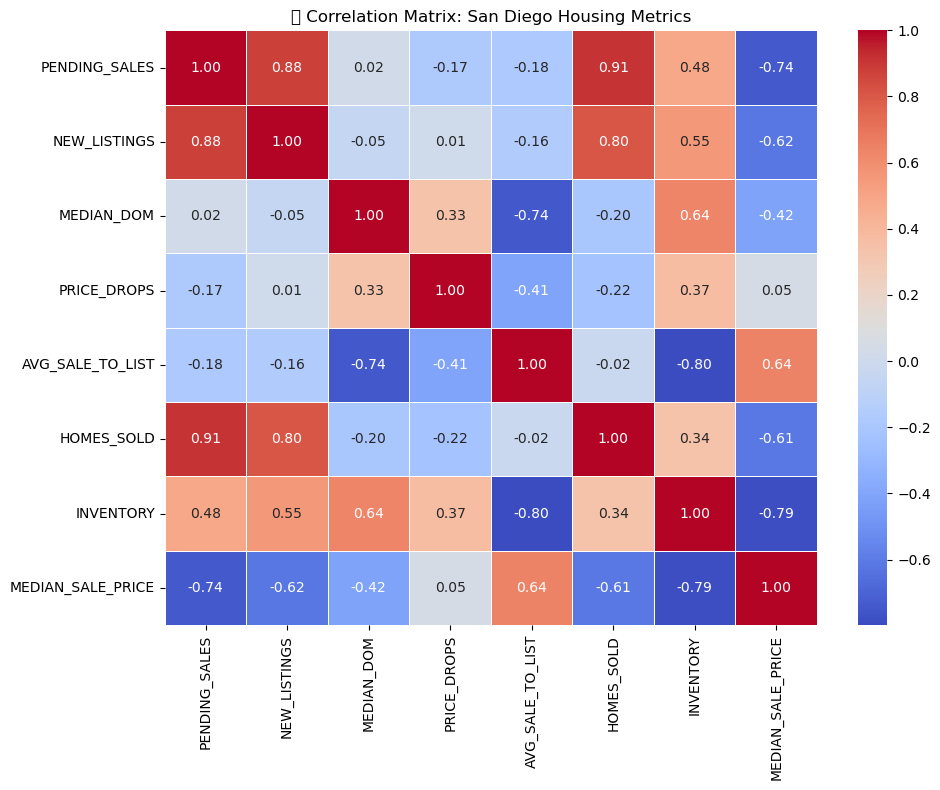

In [27]:
# Load the full processed dataset
df = pd.read_csv('../data/processed/san_diego_housing_metrics.csv', parse_dates=['PERIOD_BEGIN'])
df.set_index('PERIOD_BEGIN', inplace=True)

# Drop rows with NaNs (optional: limit to post-2020 if needed)
df_clean = df.dropna()

# Calculate Pearson correlation matrix
corr_matrix = df_clean.corr(method='pearson')

# Extract correlations with median price
price_corrs = corr_matrix['MEDIAN_SALE_PRICE'].sort_values(ascending=False)

# Print top and bottom correlations with median price
print("Top correlations with median price:")
print(price_corrs.head(5))
print("\nLowest (inverse) correlations with median price:")
print(price_corrs.tail(5))

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("🔍 Correlation Matrix: San Diego Housing Metrics")
plt.tight_layout()
plt.show()


In [28]:
# Export enriched dataset for Tableau
df_yoy_2023.to_csv('../data/processed/sd_yoy_2023.csv', index=False)
print("✅ Exported to: ../data/processed/sd_yoy_2023.csv")

✅ Exported to: ../data/processed/sd_yoy_2023.csv


In [29]:
# =============================================================================
# 2. Inventory as a Leading Indicator
# =============================================================================

# --- 2.1 Full Lag Correlation Analysis (lags 1–12) ---

df = pd.read_csv('../data/processed/san_diego_housing_metrics.csv',
                 parse_dates=['PERIOD_BEGIN'])
df.set_index('PERIOD_BEGIN', inplace=True)

corrs = []
for lag in range(1, 13):
    shifted = df['MEDIAN_SALE_PRICE'].shift(-lag)
    r = df['INVENTORY'].corr(shifted)
    corrs.append({'lag': lag, 'r': round(r, 4)})

df_lags = pd.DataFrame(corrs)
best_lag = df_lags.loc[df_lags['r'].idxmin(), 'lag']

print(df_lags.to_string(index=False))
print(f"\nStrongest inverse correlation at lag {best_lag} months")

 lag       r
   1 -0.7964
   2 -0.8156
   3 -0.8325
   4 -0.8432
   5 -0.8490
   6 -0.8528
   7 -0.8543
   8 -0.8546
   9 -0.8554
  10 -0.8575
  11 -0.8589
  12 -0.8606

Strongest inverse correlation at lag 12 months


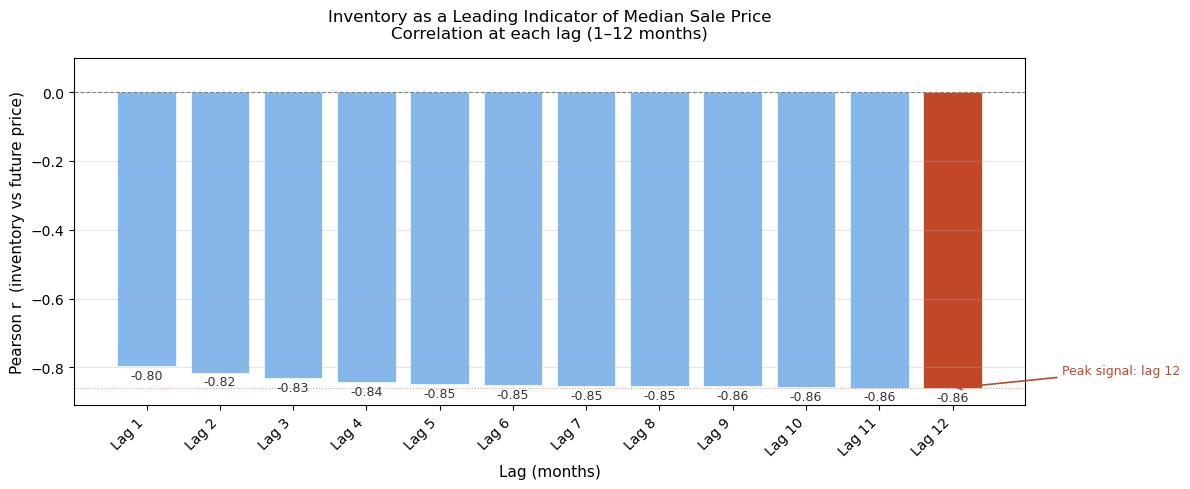

In [30]:
# --- 2.2 Lag vs Correlation Bar Chart ---

colors = ['#C04828' if lag == best_lag else '#85B7EB' for lag in df_lags['lag']]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(df_lags['lag'], df_lags['r'], color=colors, edgecolor='white', linewidth=0.5)

ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.axhline(df_lags['r'].min(), color='#C04828', linestyle=':', linewidth=0.8, alpha=0.5)

for bar, row in zip(bars, df_lags.itertuples()):
    ypos = row.r - 0.008 if row.r < 0 else row.r + 0.004
    ax.text(bar.get_x() + bar.get_width() / 2, ypos,
            f'{row.r:.2f}', ha='center', va='top' if row.r < 0 else 'bottom',
            fontsize=9, color='#333333')

ax.set_xlabel('Lag (months)', fontsize=11)
ax.set_ylabel('Pearson r  (inventory vs future price)', fontsize=11)
ax.set_title('Inventory as a Leading Indicator of Median Sale Price\nCorrelation at each lag (1–12 months)',
             fontsize=12, pad=14)
ax.set_xticks(df_lags['lag'])
ax.set_xticklabels([f'Lag {l}' for l in df_lags['lag']], rotation=45, ha='right')
ax.set_ylim(df_lags['r'].min() - 0.05, 0.1)
ax.grid(axis='y', alpha=0.3)

ax.annotate(f'Peak signal: lag {best_lag}',
            xy=(best_lag, df_lags.loc[df_lags['lag'] == best_lag, 'r'].values[0]),
            xytext=(best_lag + 1.5, df_lags['r'].min() + 0.04),
            arrowprops=dict(arrowstyle='->', color='#C04828', lw=1.2),
            fontsize=9, color='#C04828')

plt.tight_layout()
plt.savefig('../visuals/lag_correlation_chart.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
import numpy as np
from scipy import stats

In [32]:
# --- 2.3 Scatter: inventory[t] vs price[t + best_lag], colored by era ---

df_scatter = df[['INVENTORY', 'MEDIAN_SALE_PRICE']].copy()
df_scatter['future_price'] = df['MEDIAN_SALE_PRICE'].shift(-best_lag)
df_scatter = df_scatter.dropna()

# Era classification
df_scatter['era'] = 'Pre-COVID (2012–2019)'
df_scatter.loc[df_scatter.index >= '2020-01-01', 'era'] = 'COVID surge (2020–2022)'
df_scatter.loc[df_scatter.index >= '2023-01-01', 'era'] = 'Post-surge (2023–2025)'

era_styles = {
    'Pre-COVID (2012–2019)':   {'color': '#85B7EB', 'marker': 'o', 'zorder': 2},
    'COVID surge (2020–2022)': {'color': '#C04828', 'marker': 's', 'zorder': 4},
    'Post-surge (2023–2025)':  {'color': '#1D9E75', 'marker': '^', 'zorder': 3},
}

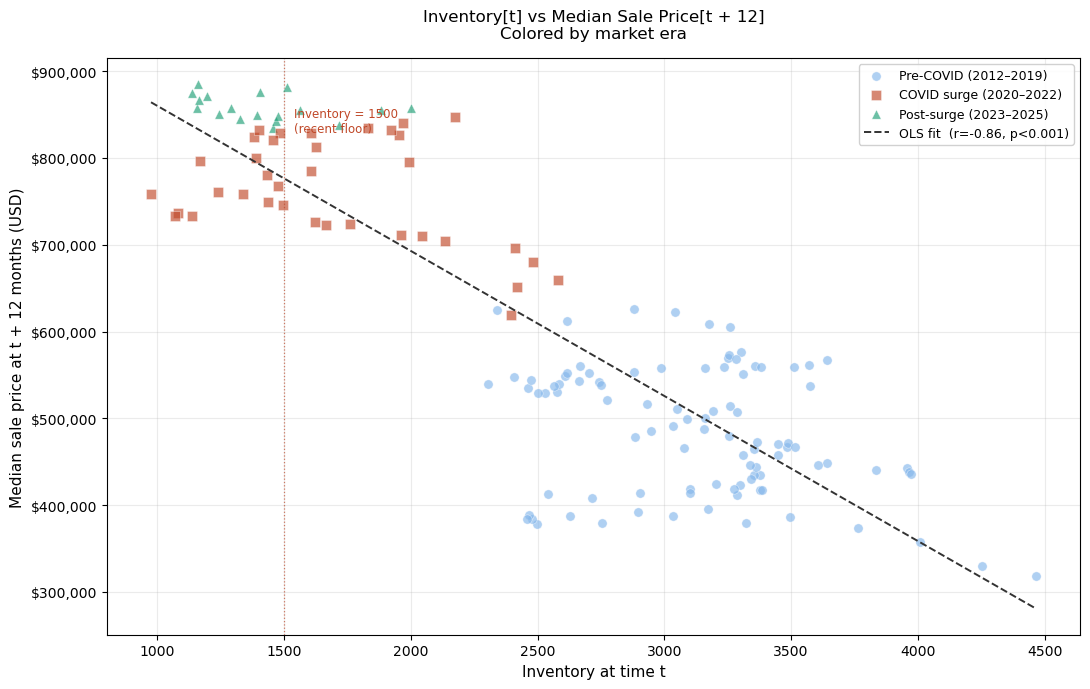


OLS summary — inventory[t] → price[t+12]
  Slope:     $-167.18 per unit of inventory
  Intercept: $1,027,277
  R²:        0.741
  p-value:   3.18e-45


In [33]:
fig, ax = plt.subplots(figsize=(11, 7))

for era, style in era_styles.items():
    subset = df_scatter[df_scatter['era'] == era]
    ax.scatter(subset['INVENTORY'], subset['future_price'],
               color=style['color'], marker=style['marker'],
               alpha=0.65, s=45, label=era, zorder=style['zorder'],
               edgecolors='white', linewidths=0.4)

# OLS regression line across full dataset
slope, intercept, r_val, p_val, se = stats.linregress(
    df_scatter['INVENTORY'], df_scatter['future_price']
)
x_line = np.linspace(df_scatter['INVENTORY'].min(), df_scatter['INVENTORY'].max(), 200)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color='#333333', linewidth=1.4, linestyle='--',
        label=f'OLS fit  (r={r_val:.2f}, p<0.001)', zorder=5)

# Annotation: signal boundary
inv_threshold = 1500
ax.axvline(inv_threshold, color='#C04828', linewidth=0.9, linestyle=':', alpha=0.7)
ax.text(inv_threshold + 40, df_scatter['future_price'].max() * 0.97,
        f'Inventory = {inv_threshold}\n(recent floor)',
        fontsize=8.5, color='#C04828', va='top')

ax.set_xlabel(f'Inventory at time t', fontsize=11)
ax.set_ylabel(f'Median sale price at t + {best_lag} months (USD)', fontsize=11)
ax.set_title(f'Inventory[t] vs Median Sale Price[t + {best_lag}]\nColored by market era',
             fontsize=12, pad=14)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig('../visuals/scatter_inventory_vs_future_price.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nOLS summary — inventory[t] → price[t+{best_lag}]')
print(f'  Slope:     ${slope:,.2f} per unit of inventory')
print(f'  Intercept: ${intercept:,.0f}')
print(f'  R²:        {r_val**2:.3f}')
print(f'  p-value:   {p_val:.2e}')

In [34]:
# --- 2.4 OLS Regression: inventory[t] → price[t + best_lag] ---

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

X = df_scatter[['INVENTORY']]
y = df_scatter['future_price']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = model.score(X, y)

print('=' * 52)
print(f'  OLS: inventory[t] → price[t+{best_lag}]')
print('=' * 52)
print(f'  Coefficient:  ${model.coef_[0]:,.2f} per inventory unit')
print(f'  Intercept:    ${model.intercept_:,.0f}')
print(f'  R²:           {r2:.3f}')
print(f'  MAE:          ${mae:,.0f}')
print(f'  RMSE:         ${rmse:,.0f}')
print('=' * 52)

# Plain-English signal statement
inv_drop = 100
price_impact = abs(model.coef_[0]) * inv_drop
print(f'\n  Signal: a {inv_drop}-unit drop in inventory is associated')
print(f'  with ~${price_impact:,.0f} higher median price {best_lag} months later.')

  OLS: inventory[t] → price[t+12]
  Coefficient:  $-167.18 per inventory unit
  Intercept:    $1,027,277
  R²:           0.741
  MAE:          $66,078
  RMSE:         $83,874

  Signal: a 100-unit drop in inventory is associated
  with ~$16,718 higher median price 12 months later.


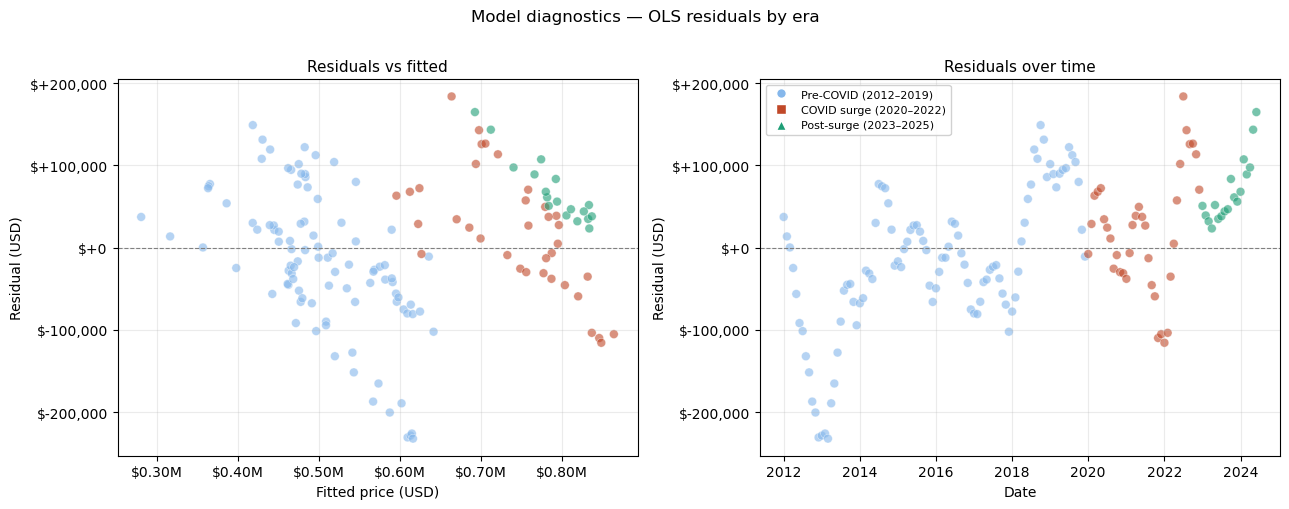

In [35]:
# --- 2.5 Residual plot — check model honesty ---

residuals = y - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Residuals vs fitted
axes[0].scatter(y_pred, residuals,
                color=[era_styles[e]['color'] for e in df_scatter['era']],
                alpha=0.6, s=40, edgecolors='white', linewidths=0.4)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('Fitted price (USD)', fontsize=10)
axes[0].set_ylabel('Residual (USD)', fontsize=10)
axes[0].set_title('Residuals vs fitted', fontsize=11)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.2f}M'))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:+,.0f}'))
axes[0].grid(alpha=0.25)

# Residuals over time
axes[1].scatter(df_scatter.index, residuals,
                color=[era_styles[e]['color'] for e in df_scatter['era']],
                alpha=0.6, s=40, edgecolors='white', linewidths=0.4)
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('Date', fontsize=10)
axes[1].set_ylabel('Residual (USD)', fontsize=10)
axes[1].set_title('Residuals over time', fontsize=11)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:+,.0f}'))
axes[1].grid(alpha=0.25)

# Era legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker=era_styles[e]['marker'],
                          color='w', markerfacecolor=era_styles[e]['color'],
                          markersize=7, label=e)
                   for e in era_styles]
axes[1].legend(handles=legend_elements, fontsize=8, framealpha=0.9)

plt.suptitle('Model diagnostics — OLS residuals by era', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('../visuals/ols_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

## Takeaway 4 — Inventory as a Structural Price Condition

A lag correlation analysis across all 12 forward horizons reveals that current
inventory levels carry a strong inverse relationship with future median sale
prices (r = −0.80 to −0.86), with signal strength remarkably stable from 1
month out to 12. This flatness is itself the finding: inventory is not a
short-term timing trigger but a durable market condition — low supply predicts
elevated prices across the entire forward window, not just the next quarter.

OLS regression quantifies the relationship: each 100-unit reduction in
inventory is associated with approximately $16,700 higher median prices 12
months later (R² = 0.74, p < 0.001, n = 155).

Residual analysis surfaces an important caveat. The model systematically
underpredicts post-2020 prices, confirming a structural price floor shift after
the pandemic that inventory alone cannot explain. The signal is real, but it
operates at different absolute price levels depending on the era. Analysts
should treat inventory as a reliable directional indicator — not a precise
price forecast — and recalibrate intercept assumptions when applying this
relationship to post-2022 data.

**Actionable signal:** When San Diego inventory falls below ~1,500 units,
this model and historical precedent suggest median prices will remain at or
above $800K across the following 12 months. Current inventory (Jun 2025:
~1,526 units) sits at that threshold.